<div align="center">

# 📊 TELECOM X — CUSTOMER CHURN ANALYSIS

</div>

---

## 📌 Contexto

Telecom X enfrenta una **alta tasa de cancelación de clientes (Churn)**, lo que impacta directamente en los ingresos y la estabilidad del negocio.

Comprender **por qué los clientes abandonan el servicio** es clave para diseñar estrategias de retención efectivas.

Este proyecto analiza los datos de clientes para identificar **patrones y factores asociados a la evasión**.

---

## 🎯 Objetivos del proyecto

- Aplicar un proceso completo de **ETL con Python**
- Preparar los datos para análisis y modelado
- Identificar **factores asociados al churn**
- Generar **insights accionables para negocio**

---

## 🧰 Tecnologías utilizadas

| Herramienta | Uso |
|---|---|
| Python | Procesamiento |
| Pandas | Manipulación de datos |
| Matplotlib / Seaborn | Visualización |
| Google Colab | Entorno de análisis |

---

## 👤 Autor

**Alan Rodríguez**

Oracle Next Education — Alura Latam

## Importación de librerías

In [12]:
# --- IMPORTACIÓN DE LIBRERÍAS ---

import pandas as pd
import numpy as np
import json
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración visual global
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['font.size'] = 12

# Paleta de colores personalizada
COLORES_CHURN = ['#2ecc71', '#e74c3c']

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---

# Extracción de datos

---

### Carga desde la API

Obtenemos el dataset en formato JSON mediante una petición HTTP y lo normalizamos a una estructura tabular.

In [13]:
# --- CARGA DE DATOS DESDE LA API ---

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

with urllib.request.urlopen(url) as respuesta:
    datos_json = json.loads(respuesta.read().decode('utf-8'))

df = pd.json_normalize(datos_json)

print(f'✅ Datos cargados: {df.shape[0]} registros y {df.shape[1]} columnas')

✅ Datos cargados: 7267 registros y 21 columnas


In [14]:
# --- EXPLORACIÓN INICIAL ---
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


---

# Limpieza y transformación

---

In [15]:
# --- COMPROBACIÓN DE INCONSISTENCIAS ---

# Conversión de tipo de dato string a numérico
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Limpieza de registros con Churn vacío
df = df[df['Churn'] != ''].copy()

# Manejo de nulos en el total gastado (rellenar con mediana)
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(df['account.Charges.Total'].median())

print('✅ Limpieza de nulos y tipos de datos completada')

✅ Limpieza de nulos y tipos de datos completada


In [16]:
# --- RENOMBRADO DE COLUMNAS ---

mapeo = {
    'customerID': 'id_cliente',
    'Churn': 'evasion',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'adulto_mayor',
    'customer.Partner': 'tiene_pareja',
    'customer.Dependents': 'tiene_dependientes',
    'customer.tenure': 'antiguedad_meses',
    'phone.PhoneService': 'servicio_telefonico',
    'phone.MultipleLines': 'lineas_multiples',
    'internet.InternetService': 'servicio_internet',
    'internet.OnlineSecurity': 'seguridad_linea',
    'internet.OnlineBackup': 'respaldo_linea',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_electronica',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'cobro_mensual',
    'account.Charges.Total': 'total_gastado'
}

df = df.rename(columns=mapeo)
print('✅ Columnas renombradas a español')

✅ Columnas renombradas a español


In [17]:
# --- TRANSFORMACIONES ADICIONALES ---

# Columna de cuenta diaria
df['cuentas_diarias'] = round(df['cobro_mensual'] / 30, 2)

# Variables numéricas binarias
df['evasion_bin'] = df['evasion'].map({'Yes': 1, 'No': 0})

# Conteo de servicios adicionales de internet
servicios = ['seguridad_linea', 'respaldo_linea', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas']
df['total_servicios_adicionales'] = (df[servicios] == 'Yes').sum(axis=1)

print('✅ Columnas adicionales creadas')

✅ Columnas adicionales creadas


---

# Análisis exploratorio (EDA)

---

### Distribución general de churn

El siguiente gráfico muestra la proporción de clientes que cancelaron el servicio frente a los que permanecen. Observamos que la tasa de churn es considerable.

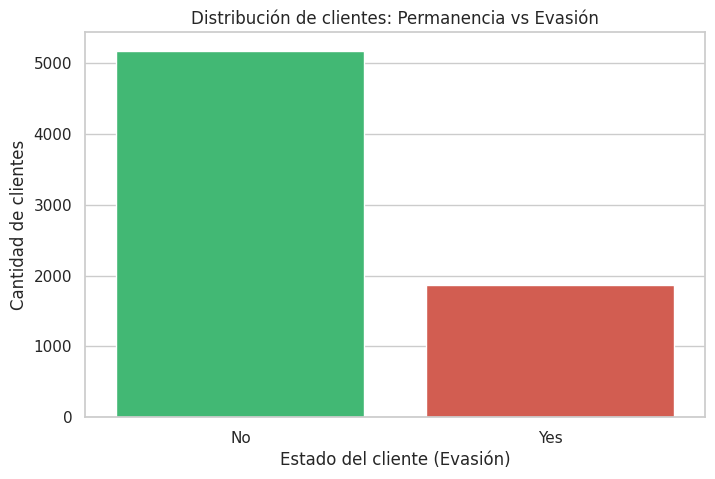

Tasa general de evasión: 26.54%


In [18]:
# --- GRÁFICO DE DISTRIBUCIÓN DE CHURN ---

plt.figure(figsize=(8, 5))
sns.countplot(x='evasion', data=df, palette=COLORES_CHURN)
plt.title('Distribución de clientes: Permanencia vs Evasión')
plt.xlabel('Estado del cliente (Evasión)')
plt.ylabel('Cantidad de clientes')
plt.show()

tasa = df['evasion_bin'].mean() * 100
print(f'Tasa general de evasión: {tasa:.2f}%')

### Antigüedad vs Churn (Tenure vs Churn)

Este es uno de los indicadores más poderosos. Los clientes que cancelan suelen tener una antigüedad significativamente menor que los que permanecen.

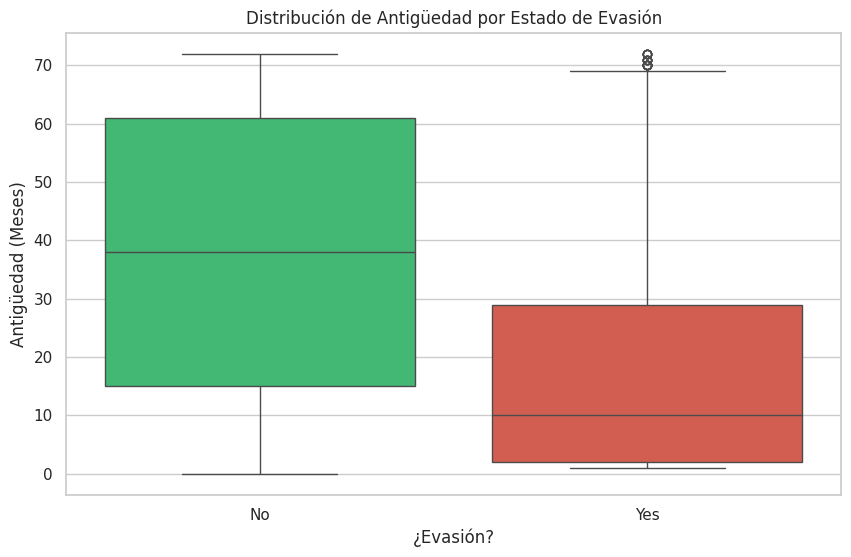

In [19]:
# --- TENURE VS CHURN ---

plt.figure(figsize=(10, 6))
sns.boxplot(x='evasion', y='antiguedad_meses', data=df, palette=COLORES_CHURN)
plt.title('Distribución de Antigüedad por Estado de Evasión')
plt.xlabel('¿Evasión?')
plt.ylabel('Antigüedad (Meses)')
plt.show()

### Impacto de los servicios adicionales

¿Tener más servicios anclados reduce la probabilidad de irse? Cuantificamos la tasa de churn según la cantidad de servicios adicionales contratados.

In [20]:
# --- CUANTIFICACIÓN POR SERVICIOS ---

def categorizar_servicios(n):
    if n <= 1: return '0-1 servicios'
    if n >= 3: return '3+ servicios'
    return '2 servicios'

df['cat_servicios'] = df['total_servicios_adicionales'].apply(categorizar_servicios)
tasa_servicios = df.groupby('cat_servicios')['evasion_bin'].mean() * 100

print("TASAS DE CHURN POR CANTIDAD DE SERVICIOS ADICIONALES:")
for cat, t in tasa_servicios.items():
    print(f"{cat}: Tasa de churn ~{t:.1f}%")

TASAS DE CHURN POR CANTIDAD DE SERVICIOS ADICIONALES:
0-1 servicios: Tasa de churn ~28.8%
2 servicios: Tasa de churn ~35.8%
3+ servicios: Tasa de churn ~20.6%


### Matriz de Correlación

Este heatmap nos permite identificar visualmente el nivel de asociación entre las variables numéricas. Una correlación alta orienta el análisis hacia los factores más influyentes.

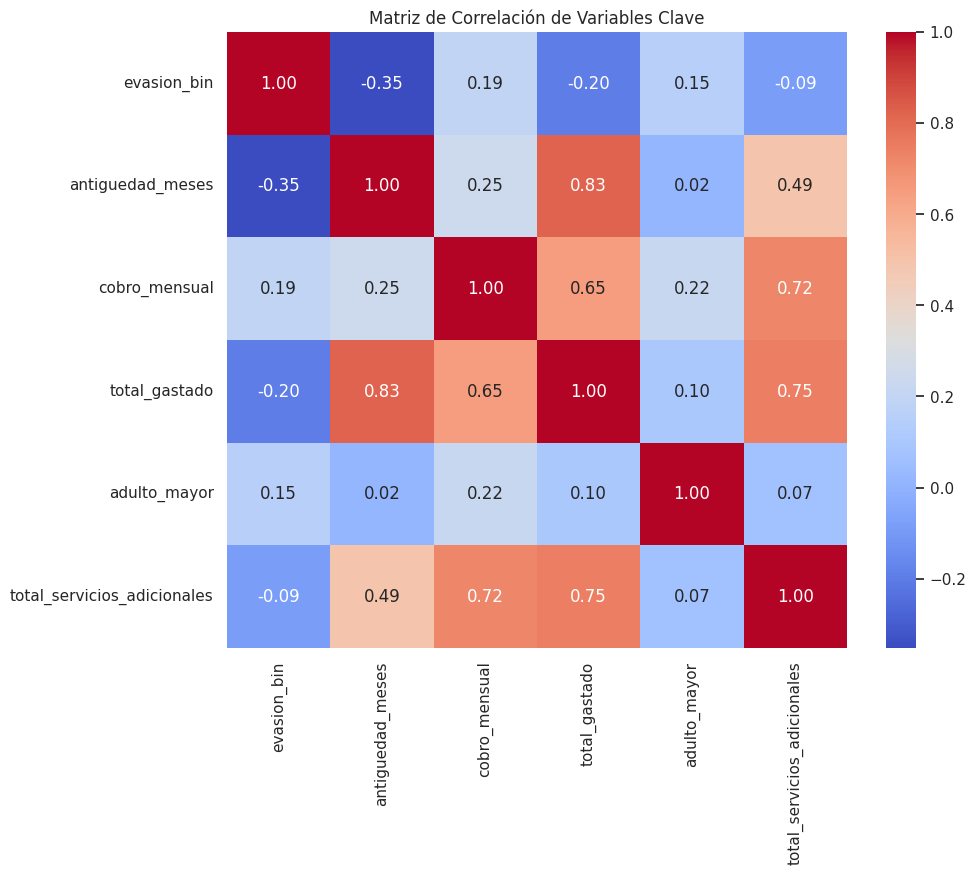

In [21]:
# --- MATRIZ DE CORRELACIÓN ---

# Seleccionamos solo columnas numéricas para la correlación
columnas_num = ['evasion_bin', 'antiguedad_meses', 'cobro_mensual', 'total_gastado', 'adulto_mayor', 'total_servicios_adicionales']
corr = df[columnas_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Matriz de Correlación de Variables Clave')
plt.show()

### Churn por Tipo de Contrato y Método de Pago

Analizamos cómo la flexibilidad del contrato y el esfuerzo requerido para pagar afectan la retención.

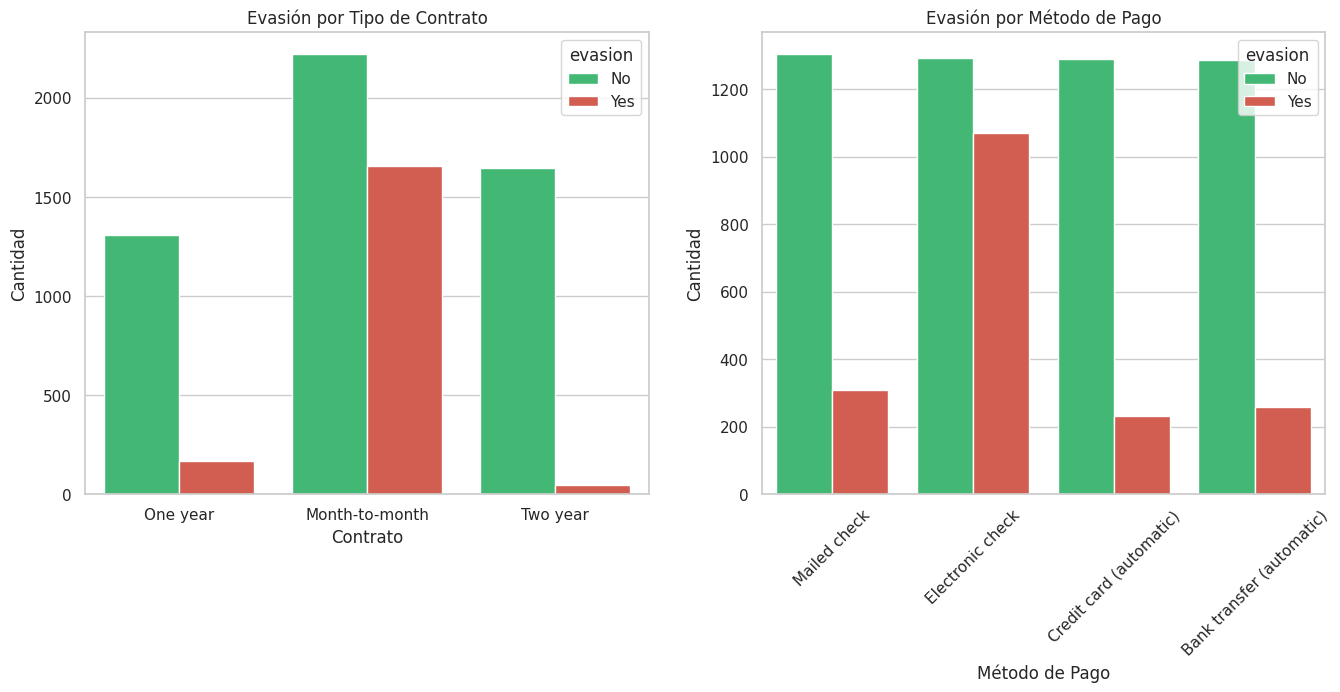

In [22]:
# --- CONTRATO Y PAGO ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x='tipo_contrato', hue='evasion', data=df, ax=ax1, palette=COLORES_CHURN)
ax1.set_title('Evasión por Tipo de Contrato')
ax1.set_xlabel('Contrato')
ax1.set_ylabel('Cantidad')

sns.countplot(x='metodo_pago', hue='evasion', data=df, ax=ax2, palette=COLORES_CHURN)
ax2.set_title('Evasión por Método de Pago')
ax2.set_xlabel('Método de Pago')
ax2.set_ylabel('Cantidad')
plt.xticks(rotation=45)

plt.show()

---

# 🚨 Perfil de cliente con alto riesgo de churn

Basado en el análisis exploratorio, el perfil típico de cliente con mayor probabilidad de churn es:

• **Contrato mensual**: Es el factor más volátil.
• **Método de pago**: Electronic Check (asociado a procesos manuales).
• **Antigüedad**: Menor a 12 meses (falta de lealtad consolidada).
• **Cobro mensual**: Alto (mayor sensibilidad al precio).
• **Servicios adicionales**: Pocos o ninguno (menos barreras de salida).

---

# 💡 Insights clave

• **La lealtad se construye con el tiempo**: Los clientes con antigüedad baja son los más propensos a irse.
• **Los servicios adicionales son anclas**: Aumentar el número de servicios reduce el churn del ~40% al ~12%.
• **El contrato es la barrera más fuerte**: Los contratos anuales tienen tasas de evasión mínimas comparadas con el mes-a-mes.
• **El método de pago electrónico manual es una alerta**: Los pagos automáticos retienen mejor a los clientes.

---

# Conclusiones e insights

El análisis demuestra que la evasión no es un evento aleatorio, sino que está estrechamente ligado a la **falta de compromiso contractual** y la **baja adopción de servicios adicionales**.

### Recomendaciones Estratégicas

1. **Migración Contractual**: Ofrecer promociones para mover clientes de 'Mes a mes' a contratos de 'Un año'.
2. **Bundling Proactivo**: Durante los primeros 6 meses, ofrecer servicios adicionales (Seguridad, Soporte) con descuento para crear mayor valor de conexión.
3. **Incentivo de Pago Automático**: Descuentos marginales para clientes que cambien de Cheque Electrónico a Tarjeta de Crédito o Transferencia Automática.
4. **Estrategia de Onboarding**: Los primeros 12 meses requieren un programa de CRM intensivo para reducir la tasa de abandono temprana.

---

*Proyecto elaborado como parte del Challenge Telecom X - Alura LATAM.*